# Authors

- David Robredo Manuel
- Duarte Novas Álvarez
- Rubén González Braña

## Imports

In [1]:
import tensorflow as tf
import keras
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import visualkeras

from keras.callbacks import EarlyStopping

from keras.utils import to_categorical

In [2]:
print("Available Physical Devices: ", tf.config.list_physical_devices())

Available Physical Devices:  [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## Functions

In [3]:
def show_image(image):

    plt.imshow(image)
    plt.axis("off")
    plt.show()

In [5]:
import copy
import cv2
import numpy as np

def canny_edge_dataset(dataset):
    canny_dataset = []
    for img_pre in dataset:
        try:
            img = copy.deepcopy(img_pre)
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            edges = cv2.Canny(gray, 150, 300)
            img[edges == 255] = (255, 0, 0)
            canny_dataset.append(img)
        except:
            print("Couldn't process image")

    return np.array(canny_dataset)


def sift_transform_dataset(dataset):
    sift_dataset = []
    for img_pre in dataset:
        try:
            img = img_pre.copy()
            sift = cv2.SIFT_create()
            keypoints = sift.detect(img, None)
            img_keypoints = cv2.drawKeypoints(img, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
            sift_dataset.append(img_keypoints)
        except:
            print("Couldn't process image")
    
    return np.array(sift_dataset)

## Preprocessing

#### LOADING DATA

We load the data and divide it into train and test. Also, we assert that there are the correct number of instances in each group.

In [15]:
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar100.load_data(label_mode="coarse")
assert X_train.shape == (50000, 32, 32, 3)
assert X_test.shape == (10000, 32, 32, 3)
assert y_train.shape == (50000, 1)
assert y_test.shape == (10000, 1)

##### Feature Extraction: Canny Edge Detection

In [7]:
X_train_canny_edge = canny_edge_dataset(X_train)
X_test_canny_edge = canny_edge_dataset(X_test)

Show an example image of the dataset

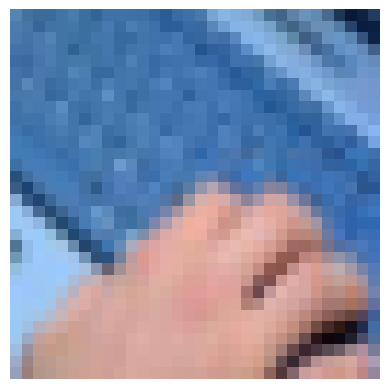

In [8]:
show_image(X_train[10])

##### Feature Extraction: SIFT Transform

In [9]:
X_train_sift_transform = sift_transform_dataset(X_train)
X_test_sift_transform = sift_transform_dataset(X_test)

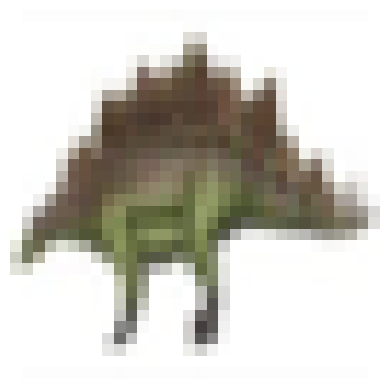

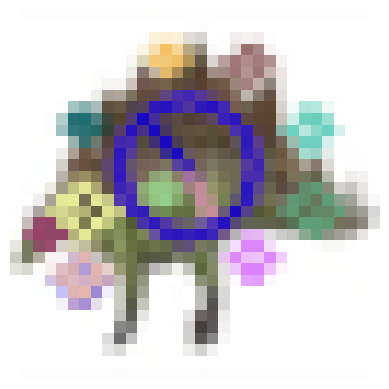

In [10]:
img_number = 1

show_image(X_train[img_number])
show_image(X_train_sift_transform[img_number])

In [16]:
y_train = y_train.flatten()
y_test = y_test.flatten()

In [17]:
X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)

We apply one hot encoding to the target labels

In [18]:
y_train = to_categorical(y_train, num_classes=20)
y_test = to_categorical(y_test, num_classes=20)

In [19]:
len(X_train), len(y_train), len(X_test), len(y_test)

(50000, 50000, 10000, 10000)

### Inception

#### Preprocessing

We apply the proper preprocessing to the data for the inception model

In [20]:
scaled_X_train = keras.applications.inception_v3.preprocess_input(x = X_train)
scaled_X_test = keras.applications.inception_v3.preprocess_input(x = X_test)

scaled_X_train_canny = keras.applications.inception_v3.preprocess_input(x = X_train_canny_edge)
scaled_X_test_canny = keras.applications.inception_v3.preprocess_input(x = X_test_canny_edge)

scaled_X_train_sift = keras.applications.inception_v3.preprocess_input(x = X_train_sift_transform)
scaled_X_test_sift = keras.applications.inception_v3.preprocess_input(x = X_test_sift_transform)

#### Creation

#### Case 1: Model with normal dataset and no training

In [21]:
input_tensor = keras.Input(shape=(32, 32, 3))

x = keras.layers.UpSampling2D(size=(10, 10), interpolation='bilinear')

base_model = keras.applications.InceptionV3(weights='imagenet', include_top=False, input_shape=(320, 320, 3))
base_model.trainable = False

model1 = keras.models.Sequential([
    input_tensor,
    x,
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dense(20, activation='softmax')
])

#### Compilation

In [22]:
model1.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#### Testing

In [23]:
model1.evaluate(scaled_X_test, y_test)

  5/313 ━━━━━━━━━━━━━━━━━━━━ 26:56 5s/step - accuracy: 0.0266 - loss: 3.1182

KeyboardInterrupt: 

In [ ]:
model1.save("Model1.h5")

#### Case 2: Model with normal dataset and trained but not the weights

In [ ]:
input_tensor = keras.Input(shape=(32, 32, 3))

x = keras.layers.UpSampling2D(size=(10, 10), interpolation='bilinear')

base_model = keras.applications.InceptionV3(weights='imagenet', include_top=False, input_shape=(320, 320, 3))
base_model.trainable = False

model2 = keras.models.Sequential([
    input_tensor,
    x,
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dense(20, activation='softmax')
])

#### Compilation

In [ ]:
model2.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#### Training

In [ ]:
history_model2 = model2.fit(
    scaled_X_train,
    y_train,
    validation_split=0.2,
    epochs=3,
)

#### Testing

In [ ]:
model2.evaluate(scaled_X_test, y_test)

In [ ]:
model2.save("Model2.h5")

In [ ]:
pd.DataFrame(history_model2.history).to_csv("Model2_Train_History.csv")
pd.DataFrame(history_model2.history).plot()

#### Case 3: Model with normal dataset and trained totally

In [ ]:
input_tensor = keras.Input(shape=(32, 32, 3))

x = keras.layers.UpSampling2D(size=(10, 10), interpolation='bilinear')

base_model = keras.applications.InceptionV3(weights='imagenet', include_top=False, input_shape=(320, 320, 3))
base_model.trainable = True

model3 = keras.models.Sequential([
    input_tensor,
    x,
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dense(20, activation='softmax')
])

#### Compilation

In [ ]:
model3.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#### Training

In [ ]:
history_model3 = model3.fit(
    scaled_X_train,
    y_train,
    validation_split=0.2,
    epochs=3,
)

#### Testing

In [ ]:
model3.evaluate(scaled_X_test, y_test)

In [ ]:
model3.save("Model3.h5")

In [ ]:
pd.DataFrame(history_model3.history).to_csv("Model3_Train_History.csv")
pd.DataFrame(history_model3.history).plot()

#### Case 4: Model with canny dataset and no trainable weights

In [ ]:
input_tensor = keras.Input(shape=(32, 32, 3))

x = keras.layers.UpSampling2D(size=(10, 10), interpolation='bilinear')

base_model = keras.applications.InceptionV3(weights='imagenet', include_top=False, input_shape=(320, 320, 3))
base_model.trainable = False

model4 = keras.models.Sequential([
    input_tensor,
    x,
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dense(20, activation='softmax')
])

#### Compilation

In [ ]:
model4.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#### Training

In [ ]:
history_model4 = model4.fit(
    scaled_X_train_canny,
    y_train,
    validation_split=0.2,
    epochs=3,
)

#### Testing

In [ ]:
model4.evaluate(scaled_X_test_canny, y_test)

In [ ]:
model4.save("Model4.h5")

In [ ]:
pd.DataFrame(history_model4.history).to_csv("Model4_Train_History.csv")
pd.DataFrame(history_model4.history).plot()

#### Case 5: Model with sift dataset and no trainable weights

In [ ]:
input_tensor = keras.Input(shape=(32, 32, 3))

x = keras.layers.UpSampling2D(size=(10, 10), interpolation='bilinear')

base_model = keras.applications.InceptionV3(weights='imagenet', include_top=False, input_shape=(320, 320, 3))
base_model.trainable = False

model5 = keras.models.Sequential([
    input_tensor,
    x,
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dense(20, activation='softmax')
])

#### Compilation

In [ ]:
model5.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#### Training

In [ ]:
history_model5 = model5.fit(
    scaled_X_train_sift,
    y_train,
    validation_split=0.2,
    epochs=3,
)

#### Testing

In [ ]:
model5.evaluate(scaled_X_test_sift, y_test)

In [ ]:
model5.save("Model5.h5")

In [ ]:
pd.DataFrame(history_model5.history).to_csv("Model5_Train_History.csv")
pd.DataFrame(history_model5.history).plot()

---

### Xception

#### Preprocessing

We apply the proper preprocessing to the data

In [ ]:
scaled_X_train = keras.applications.xception.preprocess_input(x = X_train)
scaled_X_test = keras.applications.xception.preprocess_input(x = X_test)

scaled_X_train_canny = keras.applications.xception.preprocess_input(x = X_train_canny_edge)
scaled_X_test_canny = keras.applications.xception.preprocess_input(x = X_test_canny_edge)

scaled_X_train_sift = keras.applications.xception.preprocess_input(x = X_train_sift_transform)
scaled_X_test_sift = keras.applications.xception.preprocess_input(x = X_test_sift_transform)

#### Creation

#### Case 1: Model with normal dataset and no training

In [ ]:
input_tensor = keras.Input(shape=(32, 32, 3))

x = keras.layers.UpSampling2D(size=(10, 10), interpolation='bilinear')

base_model = keras.applications.Xception(weights='imagenet', include_top=False, input_shape=(320, 320, 3))
base_model.trainable = False

model1 = keras.models.Sequential([
    input_tensor,
    x,
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dense(20, activation='softmax')
])

#### Compilation

In [ ]:
model1.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#### Testing

In [ ]:
model1.evaluate(scaled_X_test, y_test)

In [ ]:
model1.save("Model1_xception.h5")

#### Case 2: Model with normal dataset and trained but not the weights

In [ ]:
input_tensor = keras.Input(shape=(32, 32, 3))

x = keras.layers.UpSampling2D(size=(10, 10), interpolation='bilinear')

base_model = keras.applications.Xception(weights='imagenet', include_top=False, input_shape=(320, 320, 3))
base_model.trainable = False

model2 = keras.models.Sequential([
    input_tensor,
    x,
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dense(20, activation='softmax')
])

#### Compilation

In [ ]:
model2.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#### Training

In [ ]:
history_model2 = model2.fit(
    scaled_X_train,
    y_train,
    validation_split=0.2,
    epochs=3,
)

#### Testing

In [ ]:
model2.evaluate(scaled_X_test, y_test)

In [ ]:
model2.save("Model2_xception.h5")

In [ ]:
pd.DataFrame(history_model2.history).to_csv("Model2_Train_History.csv")
pd.DataFrame(history_model2.history).plot()

#### Case 3: Model with normal dataset and trained totally

In [ ]:
input_tensor = keras.Input(shape=(32, 32, 3))

x = keras.layers.UpSampling2D(size=(10, 10), interpolation='bilinear')

base_model = keras.applications.Xception(weights='imagenet', include_top=False, input_shape=(320, 320, 3))
base_model.trainable = True

model3 = keras.models.Sequential([
    input_tensor,
    x,
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dense(20, activation='softmax')
])

#### Compilation

In [ ]:
model3.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#### Training

In [ ]:
history_model3 = model3.fit(
    scaled_X_train,
    y_train,
    validation_split=0.2,
    epochs=3,
)

#### Testing

In [ ]:
model3.evaluate(scaled_X_test, y_test)

In [ ]:
model3.save("Model3_xception.h5")

In [ ]:
pd.DataFrame(history_model3.history).to_csv("Model3_Train_History.csv")
pd.DataFrame(history_model3.history).plot()

#### Case 4: Model with canny dataset and no trainable weights

In [ ]:
input_tensor = keras.Input(shape=(32, 32, 3))

x = keras.layers.UpSampling2D(size=(10, 10), interpolation='bilinear')

base_model = keras.applications.Xception(weights='imagenet', include_top=False, input_shape=(320, 320, 3))
base_model.trainable = False

model4 = keras.models.Sequential([
    input_tensor,
    x,
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dense(20, activation='softmax')
])

#### Compilation

In [ ]:
model4.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#### Training

In [ ]:
history_model4 = model4.fit(
    scaled_X_train_canny,
    y_train,
    validation_split=0.2,
    epochs=3,
)

#### Testing

In [ ]:
model4.evaluate(scaled_X_test_canny, y_test)

In [ ]:
model4.save("Model4_xception.h5")

In [ ]:
pd.DataFrame(history_model4.history).to_csv("Model4_Train_History.csv")
pd.DataFrame(history_model4.history).plot()

#### Case 5: Model with sift dataset and no trainable weights

In [ ]:
input_tensor = keras.Input(shape=(32, 32, 3))

x = keras.layers.UpSampling2D(size=(10, 10), interpolation='bilinear')

base_model = keras.applications.Xception(weights='imagenet', include_top=False, input_shape=(320, 320, 3))
base_model.trainable = False

model5 = keras.models.Sequential([
    input_tensor,
    x,
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dense(20, activation='softmax')
])

#### Compilation

In [ ]:
model5.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#### Training

In [ ]:
history_model5 = model5.fit(
    scaled_X_train_sift,
    y_train,
    validation_split=0.2,
    epochs=3,
)

#### Testing

In [ ]:
model5.evaluate(scaled_X_test_sift, y_test)

In [ ]:
model5.save("Model5_xception.h5")

In [ ]:
pd.DataFrame(history_model5.history).to_csv("Model5_Train_History.csv")
pd.DataFrame(history_model5.history).plot()

---

### Residual

#### Preprocessing

We apply again the correct preprocessing

In [ ]:
scaled_X_train = keras.applications.resnet50.preprocess_input(x = X_train)
scaled_X_test = keras.applications.resnet50.preprocess_input(x = X_test)

scaled_X_train_canny = keras.applications.resnet50.preprocess_input(x = X_train_canny_edge)
scaled_X_test_canny = keras.applications.resnet50.preprocess_input(x = X_test_canny_edge)

scaled_X_train_sift = keras.applications.resnet50.preprocess_input(x = X_train_sift_transform)
scaled_X_test_sift = keras.applications.resnet50.preprocess_input(x = X_test_sift_transform)

#### Creation

#### Case 1: Model with normal dataset and no training

In [ ]:
input_tensor = keras.Input(shape=(32, 32, 3))

x = keras.layers.UpSampling2D(size=(10, 10), interpolation='bilinear')

base_model = keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(320, 320, 3))
base_model.trainable = False

model1 = keras.models.Sequential([
    input_tensor,
    x,
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dense(20, activation='softmax')
])

#### Compilation

In [ ]:
model1.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#### Testing

In [ ]:
model1.evaluate(scaled_X_test, y_test)

In [ ]:
model1.save("Model1_resnet.h5")

#### Case 2: Model with normal dataset and trained but not the weights

In [ ]:
input_tensor = keras.Input(shape=(32, 32, 3))

x = keras.layers.UpSampling2D(size=(10, 10), interpolation='bilinear')

base_model = keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(320, 320, 3))
base_model.trainable = False

model2 = keras.models.Sequential([
    input_tensor,
    x,
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dense(20, activation='softmax')
])

#### Compilation

In [ ]:
model2.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#### Training

In [ ]:
history_model2 = model2.fit(
    scaled_X_train,
    y_train,
    validation_split=0.2,
    epochs=3,
)

#### Testing

In [ ]:
model2.evaluate(scaled_X_test, y_test)

In [ ]:
model2.save("Model2_resnet.h5")

In [ ]:
pd.DataFrame(history_model2.history).to_csv("Model2_Train_History.csv")
pd.DataFrame(history_model2.history).plot()

#### Case 3: Model with normal dataset and trained totally

In [ ]:
input_tensor = keras.Input(shape=(32, 32, 3))

x = keras.layers.UpSampling2D(size=(10, 10), interpolation='bilinear')

base_model = keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(320, 320, 3))
base_model.trainable = True

model3 = keras.models.Sequential([
    input_tensor,
    x,
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dense(20, activation='softmax')
])

#### Compilation

In [ ]:
model3.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#### Training

In [ ]:
history_model3 = model3.fit(
    scaled_X_train,
    y_train,
    validation_split=0.2,
    epochs=3,
)

#### Testing

In [ ]:
model3.evaluate(scaled_X_test, y_test)

In [ ]:
model3.save("Model3_resnet.h5")

In [ ]:
pd.DataFrame(history_model3.history).to_csv("Model3_Train_History.csv")
pd.DataFrame(history_model3.history).plot()

#### Case 4: Model with canny dataset and no trainable weights

In [ ]:
input_tensor = keras.Input(shape=(32, 32, 3))

x = keras.layers.UpSampling2D(size=(10, 10), interpolation='bilinear')

base_model = keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(320, 320, 3))
base_model.trainable = False

model4 = keras.models.Sequential([
    input_tensor,
    x,
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dense(20, activation='softmax')
])

#### Compilation

In [ ]:
model4.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#### Training

In [ ]:
history_model4 = model4.fit(
    scaled_X_train_canny,
    y_train,
    validation_split=0.2,
    epochs=3,
)

#### Testing

In [ ]:
model4.evaluate(scaled_X_test_canny, y_test)

In [ ]:
model4.save("Model4_resnet.h5")

In [ ]:
pd.DataFrame(history_model4.history).to_csv("Model4_Train_History.csv")
pd.DataFrame(history_model4.history).plot()

#### Case 5: Model with sift dataset and no trainable weights

In [ ]:
input_tensor = keras.Input(shape=(32, 32, 3))

x = keras.layers.UpSampling2D(size=(10, 10), interpolation='bilinear')

base_model = keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(320, 320, 3))
base_model.trainable = False

model5 = keras.models.Sequential([
    input_tensor,
    x,
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dense(20, activation='softmax')
])

#### Compilation

In [ ]:
model5.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#### Training

In [ ]:
history_model5 = model5.fit(
    scaled_X_train_sift,
    y_train,
    validation_split=0.2,
    epochs=3,
)

#### Testing

In [ ]:
model5.evaluate(scaled_X_test_sift, y_test)

In [ ]:
model5.save("Model5_resnet.h5")

In [ ]:
pd.DataFrame(history_model5.history).to_csv("Model5_Train_History.csv")
pd.DataFrame(history_model5.history).plot()